In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from gaussian_filter import convolution
input = r"/Users/cmdb/Quant_Bio_Project/Quant-Bio-Project/segmentation_test.tif" 
img = cv.imread(input, cv.IMREAD_GRAYSCALE)




In [2]:
def gaussian_kernal(size,std):
    kernel = np.fromfunction(
        lambda x,y: np.divide(1,2*np.pi* std**2) * 
        np.exp(
            -((x-(size-1)/2)**2 + (y-(size-1)/2)**2) / (2* std**2)
               ),
        (size,size)
    )
    return np.array(kernel/np.sum(kernel))

kernel = gaussian_kernal(3,np.sqrt(3))
low_thresh: int = 13
high_thresh: int = 50


## Apply pixel normalization

Min Pixel Value = min(image)
Max Pixel Value = max(image)

Normalized = {pixel - min pixel}/{max pixel - min pixel}

In [3]:
image = cv.filter2D(img,-1,kernel)
ret,thresh = cv.threshold(image,low_thresh,high_thresh,cv.THRESH_BINARY)
contours,hierarchy = cv.findContours(thresh, 1, 2)
test = cv.drawContours(image, contours, -5, (0, 255, 0), 1) 


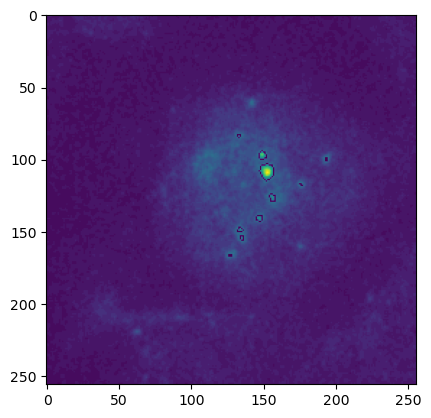

In [4]:
plt.imshow(test)
plt.show()


In [5]:


# copied = np.copy(image)
# plt.imshow(img)
# plt.show()


epsilon = 0.1*cv.arcLength(copied,True)
approx = cv.approxPolyDP(copied,epsilon,True)

	cv.findContours(	image, mode, method[, contours[, hierarchy[, offset]]]	) ->	contours, hierarchy


Finding contours?

In [6]:
contrs, hierch = cv.findContours(thresh,1,2)
print(contrs)

(array([[[126, 166]],

       [[126, 167]],

       [[128, 167]],

       [[128, 166]]], dtype=int32), array([[[134, 153]],

       [[134, 155]],

       [[135, 156]],

       [[136, 156]],

       [[136, 153]]], dtype=int32), array([[[133, 147]],

       [[133, 148]],

       [[132, 149]],

       [[132, 150]],

       [[135, 150]],

       [[136, 149]],

       [[134, 147]]], dtype=int32), array([[[146, 139]],

       [[145, 140]],

       [[145, 142]],

       [[146, 142]],

       [[147, 143]],

       [[148, 143]],

       [[149, 142]],

       [[149, 139]]], dtype=int32), array([[[155, 124]],

       [[154, 125]],

       [[154, 126]],

       [[155, 127]],

       [[155, 129]],

       [[158, 129]],

       [[158, 125]],

       [[157, 125]],

       [[156, 124]]], dtype=int32), array([[[175, 117]],

       [[176, 118]],

       [[177, 118]],

       [[176, 117]]], dtype=int32), array([[[152, 103]],

       [[151, 104]],

       [[149, 104]],

       [[148, 105]],

       [[148,

Next? Check contrs output

In [7]:
cnt = contrs[0]
M = cv.moments(cnt)
print( M )

{'m00': 2.0, 'm10': 254.0, 'm01': 333.0, 'm20': 32258.666666666664, 'm11': 42291.0, 'm02': 55444.666666666664, 'm30': 4097020.0, 'm21': 5371068.0, 'm12': 7041472.666666667, 'm03': 9231592.5, 'mu20': 0.6666666666642413, 'mu11': 0.0, 'mu02': 0.16666666666424135, 'mu30': 9.240466170012951e-10, 'mu21': 4.0381564758718014e-10, 'mu12': 6.184563972055912e-10, 'mu03': 1.2114469427615404e-09, 'nu20': 0.16666666666606034, 'nu11': 0.0, 'nu02': 0.04166666666606034, 'nu30': 1.6334990725352606e-10, 'nu21': 7.138519568953305e-11, 'nu12': 1.0932867808306863e-10, 'nu03': 2.1415558706859915e-10}


In [8]:
epsilon = cv.arcLength(cnt,True)
approx = cv.approxPolyDP(cnt,epsilon,True)

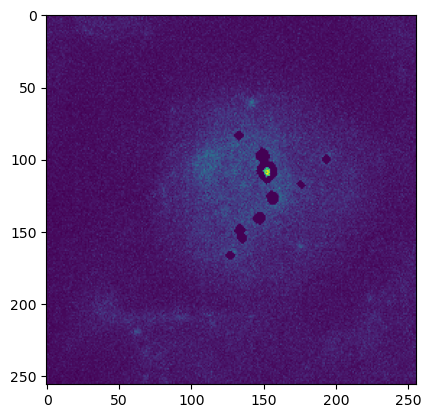

In [9]:
test = cv.drawContours(img, contrs, -1, (0,255,0), 3)

plt.imshow(test)
plt.show()


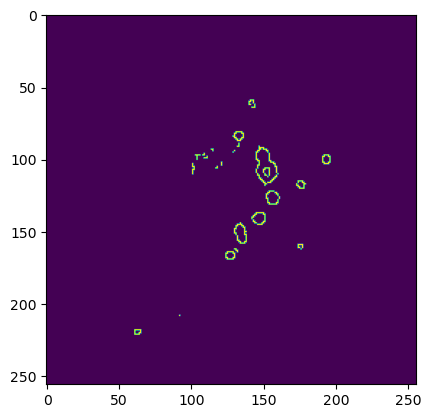

In [10]:
input_image = cv.Canny(img, 175,200,apertureSize=5, L2gradient=True)
plt.imshow(input_image)
plt.show()

## Make a copy of the image and test various applications
np.copy(image)